# **Progressive GAN**

This notebook includes the implementation of ProGAN using Tensorflow and the code to train the networks



References:

1. [Progressive Growing of GANs for Improved Quality, Stability, and Variation](https://arxiv.org/abs/1710.10196)
2. [How to Implement Progressive Growing GAN Models in Keras](https://machinelearningmastery.com/how-to-implement-progressive-growing-gan-models-in-keras/)
3. [Tutorial ProGAN](https://blog.paperspace.com/progan/)

# **Load dataset**

In [1]:
!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import callbacks
from keras import optimizers
from keras import backend
from keras.datasets import cifar10
from keras.optimizers.legacy import Adam, SGD
from keras.layers import Input, Add, Dropout, Flatten, Dense, BatchNormalization, Conv2D, MaxPooling2D, Conv2DTranspose, LeakyReLU, Reshape, Dropout, GlobalMaxPooling2D, AveragePooling2D, UpSampling2D
from keras.models import Sequential
from keras import Model

from sklearn.model_selection import train_test_split
from skimage.transform import resize
from matplotlib import pyplot as plt

In [2]:
# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

# Seperate feature X and label Y
X_train, y_train = cifar10_train["image"], cifar10_train["label"]
X_test, y_test = cifar10_test["image"], cifar10_test["label"]

# Print shapes of the entire training and test set of CIFAR 10
print("X_train shape: " + str(X_train.shape))
print("X_test shape: " + str(X_test.shape))
print("y_train shape: " + str(y_train.shape))
print("y_test shape: " + str(y_test.shape))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incomplete3TACB4/cifar10-train.tfrecord*...:   0%|          …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/3.0.2.incomplete3TACB4/cifar10-test.tfrecord*...:   0%|          |…

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)
y_train shape: (50000,)
y_test shape: (10000,)


In [3]:
# Get samples  of a certain label
label = 8 # Class '8' is ship.
train_indices = np.where(y_train == label) # Get indices of the label
train_set = X_train[train_indices] # Get train samples of the label
test_indices = np.where(y_test == label) # Get indices of the label
test_set = X_train[test_indices] # Get test samples of the label

# Print shapes of datasets of the selected class
print("train_set shape of the selected class: " + str(train_set.shape))
print("test_set shape of the selected class: " + str(test_set.shape))

# Merge the train_set and test_set because GAN does not require to have train/test split
train_set = np.concatenate((train_set, test_set), axis = 0)

# Print the shape after merged
print("train_set shape after merging: " + str(train_set.shape))

train_set shape of the selected class: (5000, 32, 32, 3)
test_set shape of the selected class: (1000, 32, 32, 3)
train_set shape after merging: (6000, 32, 32, 3)


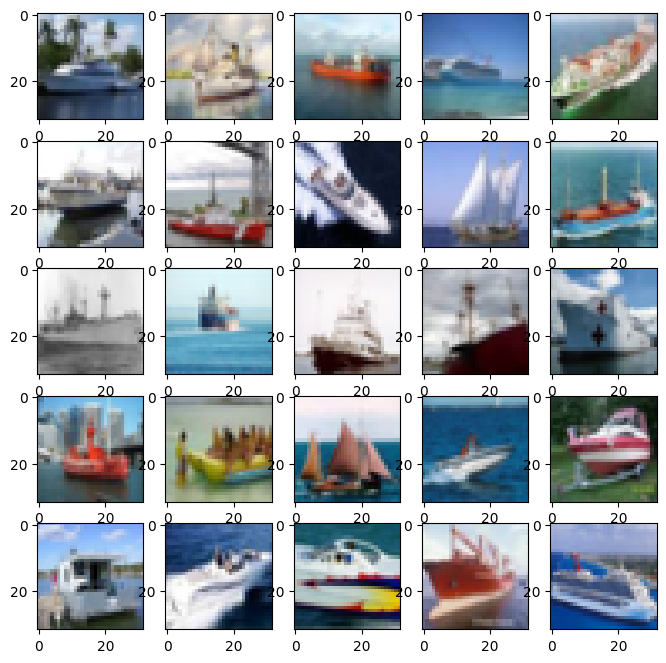

In [4]:
# Visualize some data samples of class '8' (ship)
import matplotlib.pyplot as plt
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(train_set[i])

# **Process the image**

In [5]:
train_set = train_set.astype('float32')
# Normalize from [0, 255] to [-1, 1] for tanh activation
train_set = (train_set - 127.5) / 127.5

# **Second requirement: ProGAN**

## Weight Sum layer

During the transition from a lower resolution to a higher resolution, the discriminator model have 2 input pathways. The output of new block that is downsampled and output of the old input processing layer are combined using weighted average, which is control by a hyperparam called *alpha*

In [6]:
class WeightedSum(Add):
  """Layer use when fading in a new higher-resolution input image and block"""
  # Init
  def __init__(self, alpha = 0.0, **kwargs):
    super(WeightedSum, self).__init__(**kwargs)
    self.alpha = backend.variable(alpha, name='ws_alpha') # Hyperparam to control contribution of each input

  # Output weighted sum of inputs
  def _merge_function(self, inputs):
    # Check if is have 2 inputs or not
    assert (len(inputs) == 2)

    # Output = ((1 – alpha) * fromRGB) + (alpha * NewBlock)
    output = ((1.0 - self.alpha) * inputs[0]) + (self.alpha * inputs[1])

    return output

## Build the Discriminator

In [7]:
def add_discriminator_block(old_model, n_input_layers = 3):
  """
  Returning a list of 2 defined models (straight-through and fade-in).
  """

  # Get the shape of existing model
  input_shape = list(old_model.input.shape)

  # Define new input shape double the size of existing model
  new_input_shape = (int(input_shape[-2])*2, int(input_shape[-2])*2, input_shape[-1])
  input_image = Input(shape = new_input_shape)

  # Define new input processing layer
  d = Conv2D(64, (1, 1), padding  = 'same')(input_image)
  d = LeakyReLU(alpha = 0.2)(d)

  # Define new block
  d = Conv2D(128, (3, 3), padding='same')(d)
  d = LeakyReLU(alpha = 0.2)(d)

  d = Conv2D(64, (3, 3), padding='same')(d)
  d = LeakyReLU(alpha = 0.2)(d)

  d = AveragePooling2D()(d)

  block_new = d

  # Skip the input, 1x1 and activation for the old model
  for i in range(n_input_layers, len(old_model.layers)):
    d = old_model.layers[i](d)

  # Define the straight-through model
  model1 = Model(input_image, d)

  # Compile model
  model1.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate = 0.0001, beta_1 = 0.5), metrics=['accuracy'])

  # Downsample the new larger image
  downsample = AveragePooling2D()(input_image)
  # Connect old input processing to downsampled new input
  block_old = old_model.layers[1](downsample)
  block_old = old_model.layers[2](block_old)

  # Fade in output of old model input layer with new input
  d = WeightedSum()([block_old, block_new])

  # Skip input, 1x1 and activation for old model
  for i in range(n_input_layers, len(old_model.layers)):
    d = old_model.layers[i](d)

  # Define straight-through model
  model2 = Model(input_image, d)

  # Compile model
  model2.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate = 0.0001, beta_1=0.5), metrics=['accuracy'])

  return [model1, model2]

In [8]:
def define_discriminator(n_blocks, input_shape=(4, 4, 3)):
  """ Define base model that expects 4x4 color image as input,
  then repeatedly add blocks to create new version of discriminator model.

  Return a list of models, each item in list is a two-element list
  contains:
    - The straight-through version of model at that resolution
    - Fade-in version of model for that resolution.
  """
  model_list = list()

  # Base model input
  input_image = Input(shape = input_shape)

  # Conv 1x1
  d = Conv2D(64, (1, 1), padding='same')(input_image)
  d = LeakyReLU(alpha=0.2)(d)

  # Conv 3x3
  d = Conv2D(128, (3, 3), padding='same')(d)
  d = LeakyReLU(alpha=0.2)(d)

  # Conv 3x3
  d = Conv2D(256, (3, 3), padding='same')(d)
  d = LeakyReLU(alpha = 0.2)(d)

  # Dense output layer
  d = Flatten()(d)
  d = Dropout(0.5)(d)
  out_class = Dense(1, activation='sigmoid')(d)

  # Define model
  model = Model(input_image, out_class)

  # Compile model
  model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate = 0.0001, beta_1=0.5), metrics=['accuracy'])

  # Store model
  model_list.append([model, model])

  # Create submodels
  for i in range(1, n_blocks):
    # Prior model without fade-on
    old_model = model_list[i - 1][0]

    # Create new model for next resolution
    models = add_discriminator_block(old_model)

    # Store model
    model_list.append(models)

  return model_list

# Create a sample of Discriminator structure that have 4 blocks
sample_discriminators = define_discriminator(4)
# Show the fade-in version of the first Discrim model, resolution 4x4
sample_discriminators[0][1].summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 4, 4, 3)]         0         
                                                                 
 conv2d (Conv2D)             (None, 4, 4, 64)          256       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 4, 64)          0         
                                                                 
 conv2d_1 (Conv2D)           (None, 4, 4, 128)         73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 4, 128)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 256)         295168    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 4, 4, 256)         0     

## Build the Generator

In [9]:
def add_generator_block(old_model):
  """
  Expand a given model and return both new generator model with added block
  and a version of model with fading in of new block
  """

  # Get the end of the last block
  block_end = old_model.layers[-2].output

  # Upsample
  upsampling = UpSampling2D()(block_end)

  # Define new block
  g = Conv2D(128, (3, 3), padding='same')(upsampling)
  g = LeakyReLU(alpha=0.2)(g)

  g = Conv2D(64, (3, 3), padding='same')(g)
  g = LeakyReLU(alpha=0.2)(g)

  # Add new output layer
  output_image = Conv2D(3, (1, 1), activation='tanh', padding='same', kernel_initializer='random_normal')(g)

  # Define model
  model1 = Model(old_model.input, output_image)

  # Get the output layer from old model
  output_old = old_model.layers[-1]

  # Connect the upsampling to the old output layer
  output_image2 = output_old(upsampling)

  # Define new output image as the weighted sum of old and new model
  merged = WeightedSum()([output_image2, output_image])

  # Define model
  model2 = Model(old_model.input, merged)
  return [model1, model2]

In [10]:
def define_generator(latent_dim, n_blocks, input_dim = 4):
  """
  Taking size of latent space and number of blocks to create models
  from baseline model.

  Baseline model is defined outputting a color image with shape 4x4,
  controlled by default arg input_dim
  """
  model_list = list()

  # Base model latent input
  input_latent = Input(shape=(latent_dim,))

  # Linear scale up to activation maps
  g = Dense(256 * input_dim * input_dim)(input_latent)
  g = Reshape((input_dim, input_dim, 256))(g)

  # Conv 3x3 input block
  g = Conv2D(128, (3, 3), padding='same')(g)
  g = LeakyReLU(alpha=0.2)(g)

  # Conv 3x3
  g = Conv2D(64, (3, 3), padding='same')(g)
  g = LeakyReLU(alpha = 0.2)(g)

  # Conv 1x1, output block
  output_image = Conv2D(3, (1,1), activation='tanh', padding='same')(g)

  # Define model
  model = Model(input_latent, output_image)

  # Store model
  model_list.append([model, model])

  # Create submodels
  for i in range(1, n_blocks):
    # Get prior model without fade-on
    old_model = model_list[i-1][0]

    # Create new model for next resolution
    models = add_generator_block(old_model)

    # Store model
    model_list.append(models)

  return model_list

# Create a sample of Generator structure that have 4 blocks
sample_generators = define_generator(256, 4)
# Show the fade-in version of the first Generator model, resolution 4x4
sample_generators[0][1].summary()

Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 256)]             0         
                                                                 
 dense_1 (Dense)             (None, 4096)              1052672   
                                                                 
 reshape (Reshape)           (None, 4, 4, 256)         0         
                                                                 
 conv2d_12 (Conv2D)          (None, 4, 4, 128)         295040    
                                                                 
 leaky_re_lu_12 (LeakyReLU)  (None, 4, 4, 128)         0         
                                                                 
 conv2d_13 (Conv2D)          (None, 4, 4, 64)          73792     
                                                                 
 leaky_re_lu_13 (LeakyReLU)  (None, 4, 4, 64)          0   

## Build the ProGAN

In [11]:
def define_progan(discriminators, generators):
  model_list = list()

  # Create ProGAN models
  for i in range(len(discriminators)):
    g_models, d_models = generators[i], discriminators[i]

    # Straight-through model
    d_models[0].trainable = False
    model1 = Sequential()
    model1.add(g_models[0])
    model1.add(d_models[0])
    model1.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate = 0.0001, beta_1 =0.5))

    # Fade-in model
    d_models[1].trainable = False
    model2 = Sequential()
    model2.add(g_models[1])
    model2.add(d_models[1])
    model2.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))

    # Store model
    model_list.append([model1, model2])

  return model_list

## Utils function

In [12]:
def update_fadein(models, step, n_steps):
  """
  Update the alpha value in each training iteration.
  """
  # Calculate current alpha (linear from 0 to 1)
  alpha = step / float(n_steps - 1)

  # Update alpha for each model
  for model in models:
    for layer in model.layers:
      if isinstance(layer, WeightedSum):
        backend.set_value(layer.alpha, alpha)

In [13]:
def scale_dataset(images, new_shape):
  """Scale images to preferred size"""
  images_list = list()

  for image in images:
    # resize with nearest neighbor interpolation
    new_image = resize(image, new_shape, 0)

    # Store
    images_list.append(new_image)

  return np.asarray(images_list)

In [14]:
from numpy.random import randn, randint
from numpy import zeros, ones, vstack

# Generate random latent vectors as input for Generator
def generate_latent_points(latent_dim, n_samples):
    # Generate points in the latent space
    x_input = randn(latent_dim * n_samples)

    # Reshape to a batch of inputs for the Generator
    x_input = x_input.reshape(n_samples, latent_dim)

    return x_input

# Select real samples from the real dataset for training purpose
def generate_real_samples(dataset, n_samples):
    # Generate random n_samples sample indices from the dataset
    ix = randint(0, dataset.shape[0], n_samples)

    # Get the images from the list of indices
    X = dataset[ix]

    # Generate labels for the real samples (label=1)
    y = ones((n_samples, 1))

    return X, y # Return the real images and labels.

# Use Generator to generate n_samples fake samples
def generate_fake_samples(g_model, latent_dim, n_samples):
    # Generate random latent vectors as input for Generator
    x_input = generate_latent_points(latent_dim, n_samples)

    # Generate fake data samples by passing the random latent vectors through the Generator
    X = g_model.predict(x_input)

    # Generate labels for the fake samples (label=0)
    y = zeros((n_samples, 1))

    return X, y # Return the fake images and labels.

In [15]:
def summarize_performance(status, g_model, d_model, progan_model, latent_dim, n_samples = 25):
  """
  Generate samples and save as a plot and save the model
  """
  gen_shape = g_model.output_shape
  name= '%03dx%03d-%s' % (gen_shape[1], gen_shape[2], status)

  # Generate images
  X, _ = generate_fake_samples(g_model, latent_dim, n_samples)

  # Unnormalize values
  X = ((X * 127.5) + 127.5).astype(np.uint8)

  # Plot image
  square = int(np.sqrt(n_samples))
  for i in range(n_samples):
    plt.subplot(square, square, 1 + i)
    plt.axis('off')
    plt.imshow(X[i])

  # Save plot to file
  filename1 = 'plot_%s.png' % (name)
  plt.savefig(filename1)
  plt.close()

  # Save generator model
  filename2 = 'g_model_%s.sav' % (name)
  g_model.save(filename2)

  # Saving the discriminator model
  filename3 = 'd_model_%s.sav' % (name)
  d_model.save(filename3)

  # Saving the ProGAN model
  filename4 = 'progan_model_%s.sav' % (name)
  progan_model.save(filename4)

## Training process

In [16]:
def train_epochs(g_model, d_model, progan_model, dataset, latent_dim, n_epochs = 50, n_batch = 128, fadein=False):
  # Calculate the number of batches per training epoch
  bat_per_epo = int(dataset.shape[0] / n_batch)

  # Calculate the number of training iter
  n_steps = bat_per_epo * n_epochs

  # Calculate size of half a batch of samples
  half_batch = int(n_batch / 2)

  g_loss_values = []
  d_loss_values = []

  # Manually enumerate epochs
  for step in range(n_steps):
    # Update alpha of Weighted Sum
    if fadein:
      update_fadein([g_model, d_model, progan_model], step, n_steps)

    # Prepare real and fake samples
    X_real, y_real = generate_real_samples(dataset, half_batch)
    X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)

    # Create training set for the discriminator: half-batch real and half-batch fake
    X, y = vstack((X_real, X_fake)), vstack((y_real, y_fake))

    # Update discriminator model weights
    d_loss, _ = d_model.train_on_batch(X, y)

    # Generate random latent vectors as input for Generator
    X_gan = generate_latent_points(latent_dim, n_batch)

    # Generate inverted labels for the fake samples to train the Generator
    y_gan = np.ones((n_batch, 1))

    # Train the generator
    g_loss = progan_model.train_on_batch(X_gan, y_gan)

    # Training log
    epoch = np.ceil((step + 1) / bat_per_epo) # Current epoch
    pre_iter = (epoch - 1) * bat_per_epo # Previous iteration
    iter = step + 1 - pre_iter # Current iteration
    print('Epoch %d, Iteration %d/%d, D_loss=%.3f, G_loss=%.3f' % (epoch, iter, bat_per_epo, d_loss, g_loss))

    # Add loss values to historial arrays
    d_loss_values.append(d_loss)
    g_loss_values.append(g_loss)

  return d_loss_values, g_loss_values

In [17]:
def train(g_models, d_models, progan_models, dataset, latent_dim, epoch_norm, epoch_fadein, n_batch):
  # Fit baseline model
  g_normal, d_normal, progan_normal = g_models[0][0], d_models[0][0], progan_models[0][0]

  # Scale dataset to appropriate size
  gen_shape = g_normal.output_shape
  scaled_data = scale_dataset(dataset, gen_shape[1:])
  print('Scaled Data', scaled_data.shape)

  # Train normal or straight-through models
  train_epochs(g_normal, d_normal, progan_normal, scaled_data, latent_dim ,epoch_norm[0], n_batch[0])
  summarize_performance('tuned', g_normal, d_normal, progan_normal, latent_dim)

  # Process each level of growth
  for i in range(1, len(g_models)):
    # Retrieve models for this level of growth
    [g_normal, g_fadein] = g_models[i]
    [d_normal, d_fadein] = d_models[i]
    [progan_normal, progan_fadein] = progan_models[i]

    # Scale dataset to appropriate size
    gen_shape = g_normal.output_shape
    scaled_data = scale_dataset(dataset, gen_shape[1:])
    print('Scaled Data', scaled_data.shape)

    # Train fade-in model for next level of growth
    d_loss_fadein, g_loss_fadein = train_epochs(g_fadein, d_fadein, progan_fadein, scaled_data, latent_dim,epoch_fadein[i], n_batch[i], True)
    summarize_performance('faded', g_fadein, d_fadein, progan_fadein, latent_dim)

    # Train normal or straight-through models
    d_loss_norm, g_loss_norm = train_epochs(g_normal, d_normal, progan_normal, scaled_data, latent_dim, epoch_norm[i], n_batch[i])
    summarize_performance('tuned', g_normal, d_normal, progan_normal, latent_dim)

  return d_loss_fadein, g_loss_fadein, d_loss_norm, g_loss_norm

## Main code

In [18]:
latent_dim = 256 # Size of latent space
n_blocks = 4 # Grow from [4x4, 8x8, 16x16, 32x32]
epochs = [30, 40, 50, 50]
batch_size = [128, 128, 128, 128]

# Create models
g_models = define_generator(latent_dim, n_blocks)
d_models = define_discriminator(n_blocks)
progan_models = define_progan(d_models, g_models)

# Train ProGAN
d_loss_fadein, g_loss_fadein, d_loss_norm, g_loss_norm = train(g_models, d_models, progan_models, dataset = train_set, latent_dim=latent_dim, epoch_norm = epochs, epoch_fadein = epochs, n_batch = batch_size)

Scaled Data (6000, 4, 4, 3)
2/2 [==============================] - 4s 14ms/step
Epoch 1, Iteration 1/46, D_loss=0.697, G_loss=0.694
2/2 [==============================] - 0s 9ms/step
Epoch 1, Iteration 2/46, D_loss=0.691, G_loss=0.698
2/2 [==============================] - 0s 9ms/step
Epoch 1, Iteration 3/46, D_loss=0.684, G_loss=0.695
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 4/46, D_loss=0.680, G_loss=0.692
2/2 [==============================] - 0s 7ms/step
Epoch 1, Iteration 5/46, D_loss=0.675, G_loss=0.689
2/2 [==============================] - 0s 7ms/step
Epoch 1, Iteration 6/46, D_loss=0.675, G_loss=0.682
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.668, G_loss=0.680
2/2 [==============================] - 0s 8ms/step
Epoch 1, Iteration 8/46, D_loss=0.671, G_loss=0.669
2/2 [==============================] - 0s 8ms/step
Epoch 1, Iteration 9/46, D_loss=0.672, G_loss=0.661
2/2 [==============================] - 0s 4m

Scaled Data (6000, 8, 8, 3)
2/2 [==============================] - 0s 9ms/step
Epoch 1, Iteration 1/46, D_loss=0.702, G_loss=0.700
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 2/46, D_loss=0.699, G_loss=0.698
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 3/46, D_loss=0.698, G_loss=0.699
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 4/46, D_loss=0.691, G_loss=0.701
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 5/46, D_loss=0.691, G_loss=0.702
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 6/46, D_loss=0.688, G_loss=0.704
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.686, G_loss=0.710
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 8/46, D_loss=0.685, G_loss=0.707
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 9/46, D_loss=0.681, G_loss=0.705
2/2 [==============================] - 0s 5ms

2/2 [==============================] - 0s 7ms/step
Epoch 1, Iteration 1/46, D_loss=0.675, G_loss=0.719
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 2/46, D_loss=0.672, G_loss=0.704
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 3/46, D_loss=0.682, G_loss=0.693
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 4/46, D_loss=0.680, G_loss=0.698
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 5/46, D_loss=0.667, G_loss=0.697
2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 6/46, D_loss=0.678, G_loss=0.682
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.691, G_loss=0.688
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 8/46, D_loss=0.690, G_loss=0.685
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 9/46, D_loss=0.686, G_loss=0.697
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 10/

Scaled Data (6000, 16, 16, 3)
2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 1/46, D_loss=0.687, G_loss=0.697
2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 2/46, D_loss=0.701, G_loss=0.699
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 3/46, D_loss=0.701, G_loss=0.688
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 4/46, D_loss=0.694, G_loss=0.684
2/2 [==============================] - 0s 7ms/step
Epoch 1, Iteration 5/46, D_loss=0.690, G_loss=0.673
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 6/46, D_loss=0.694, G_loss=0.676
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.697, G_loss=0.669
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 8/46, D_loss=0.696, G_loss=0.667
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 9/46, D_loss=0.698, G_loss=0.669
2/2 [==============================] - 0s 5

2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 1/46, D_loss=0.668, G_loss=0.801
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 2/46, D_loss=0.637, G_loss=0.794
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 3/46, D_loss=0.632, G_loss=0.793
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 4/46, D_loss=0.649, G_loss=0.794
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 5/46, D_loss=0.647, G_loss=0.766
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 6/46, D_loss=0.650, G_loss=0.765
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.666, G_loss=0.727
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 8/46, D_loss=0.643, G_loss=0.807
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 9/46, D_loss=0.677, G_loss=0.748
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 10/

Scaled Data (6000, 32, 32, 3)
2/2 [==============================] - 0s 7ms/step
Epoch 1, Iteration 1/46, D_loss=0.638, G_loss=0.787
2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 2/46, D_loss=0.632, G_loss=0.813
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 3/46, D_loss=0.645, G_loss=0.937
2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 4/46, D_loss=0.637, G_loss=0.871
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 5/46, D_loss=0.641, G_loss=0.803
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 6/46, D_loss=0.634, G_loss=0.880
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.638, G_loss=0.803
2/2 [==============================] - 0s 7ms/step
Epoch 1, Iteration 8/46, D_loss=0.628, G_loss=0.890
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 9/46, D_loss=0.679, G_loss=0.881
2/2 [==============================] - 0s 5

2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 1/46, D_loss=0.663, G_loss=0.828
2/2 [==============================] - 0s 6ms/step
Epoch 1, Iteration 2/46, D_loss=0.596, G_loss=0.695
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 3/46, D_loss=0.666, G_loss=0.945
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 4/46, D_loss=0.597, G_loss=0.969
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 5/46, D_loss=0.634, G_loss=0.860
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 6/46, D_loss=0.656, G_loss=0.850
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 7/46, D_loss=0.635, G_loss=0.803
2/2 [==============================] - 0s 8ms/step
Epoch 1, Iteration 8/46, D_loss=0.633, G_loss=0.815
2/2 [==============================] - 0s 4ms/step
Epoch 1, Iteration 9/46, D_loss=0.590, G_loss=0.791
2/2 [==============================] - 0s 5ms/step
Epoch 1, Iteration 10/

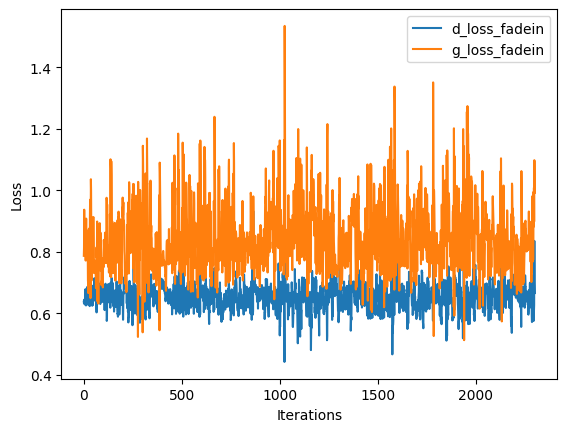

In [19]:
### Plot the training loss of the Generator and the Discriminator fadein
### at last level

# Initialize values of x-axis (iterations)
dx = np.linspace(0, len(d_loss_fadein), len(d_loss_fadein))
gx = np.linspace(0,len(g_loss_fadein), len(d_loss_fadein))

# Plot the training loss of G and D
plt.plot(dx, d_loss_fadein)
plt.plot(gx, g_loss_fadein)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.legend(['d_loss_fadein', 'g_loss_fadein'], loc='upper right')
plt.show()

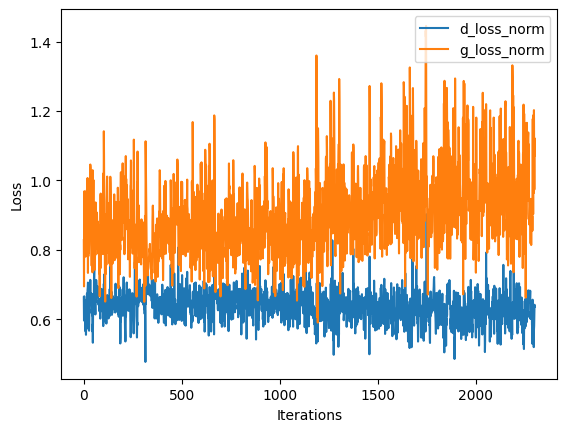

In [20]:
### Plot the training loss of the Generator and the Discriminator normal
### at last level

# Initialize values of x-axis (iterations)
dx = np.linspace(0, len(d_loss_norm), len(d_loss_norm))
gx = np.linspace(0,len(g_loss_norm), len(d_loss_norm))

# Plot the training loss of G and D
plt.plot(dx, d_loss_norm)
plt.plot(gx, g_loss_norm)
plt.ylabel('Loss')
plt.xlabel('Iterations')
plt.legend(['d_loss_norm', 'g_loss_norm'], loc='upper right')
plt.show()

## Load the models & Plot generate images

### 4x4 images

4/4 [==============================] - 0s 56ms/step


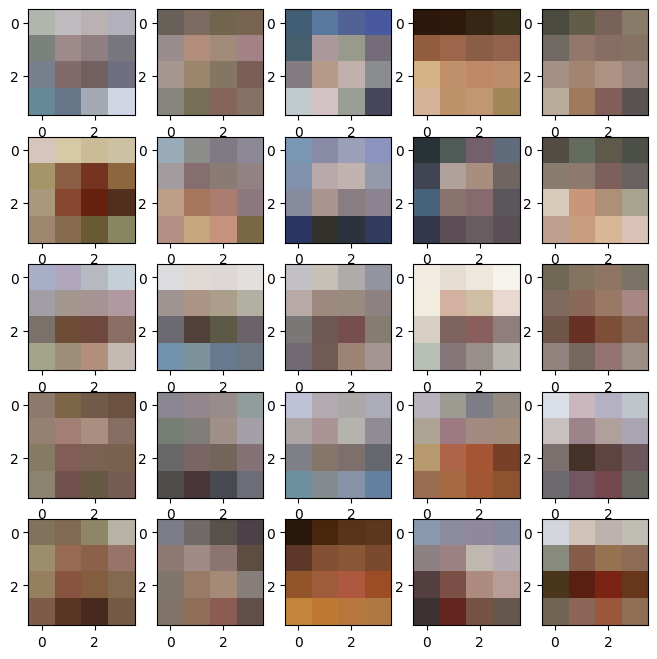

In [21]:
# Load Generator from final saved model

g_model = keras.models.load_model("g_model_004x004-tuned.sav")

# Generate 100 fake images by passing 100-dimensional random vectors through the Generator.
X_fake, _ = generate_fake_samples(g_model, 256, 100)

# Unnormalize to visualize image
X_fake = ((X_fake * 127.5) + 127.5).astype(np.uint8)

# Visualize the generated images
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(X_fake[i])

### 8x8 images

4/4 [==============================] - 0s 54ms/step


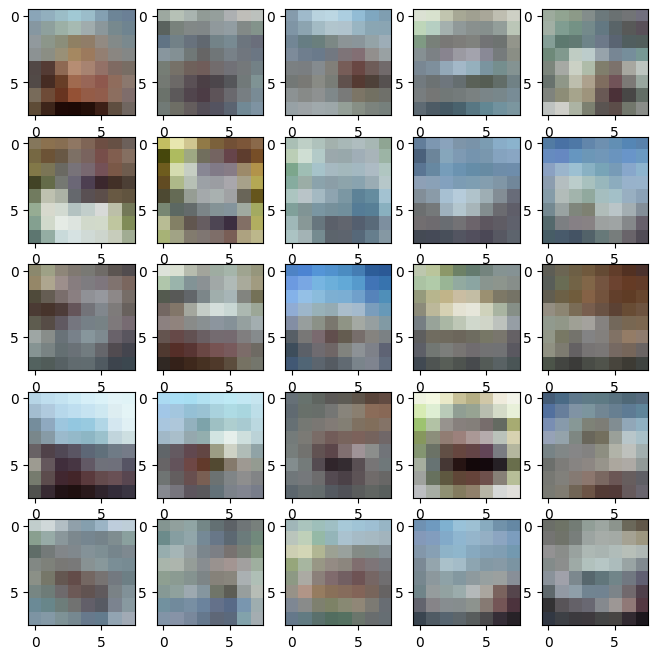

In [22]:
# Load Generator from final saved model

g_model = keras.models.load_model("g_model_008x008-tuned.sav")

# Generate 100 fake images by passing 100-dimensional random vectors through the Generator.
X_fake, _ = generate_fake_samples(g_model, 256, 100)

# Unnormalize to visualize image
X_fake = ((X_fake * 127.5) + 127.5).astype(np.uint8)

# Visualize the generated images
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(X_fake[i])

### 16x16 images

4/4 [==============================] - 0s 58ms/step


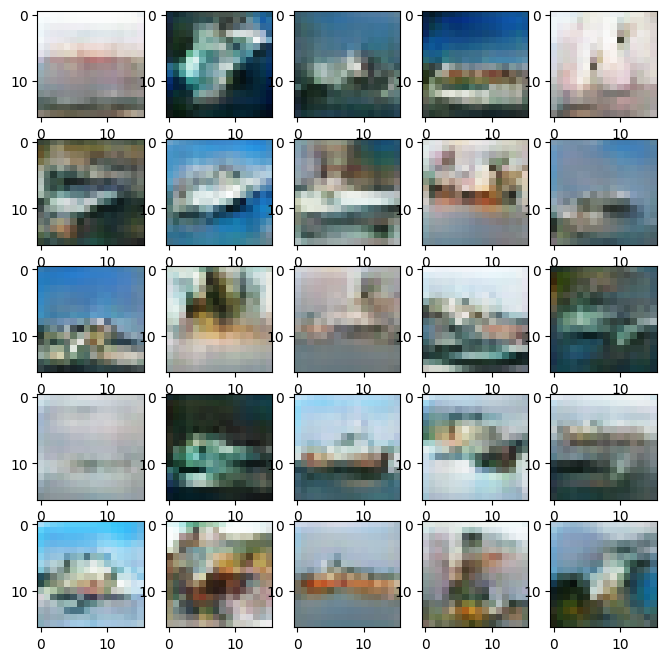

In [23]:
# Load Generator from final saved model

g_model = keras.models.load_model("g_model_016x016-tuned.sav")

# Generate 100 fake images by passing 100-dimensional random vectors through the Generator.
X_fake, _ = generate_fake_samples(g_model, 256, 100)

# Unnormalize to visualize image
X_fake = ((X_fake * 127.5) + 127.5).astype(np.uint8)

# Visualize the generated images
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(X_fake[i])

### 32x32 images

4/4 [==============================] - 0s 5ms/step


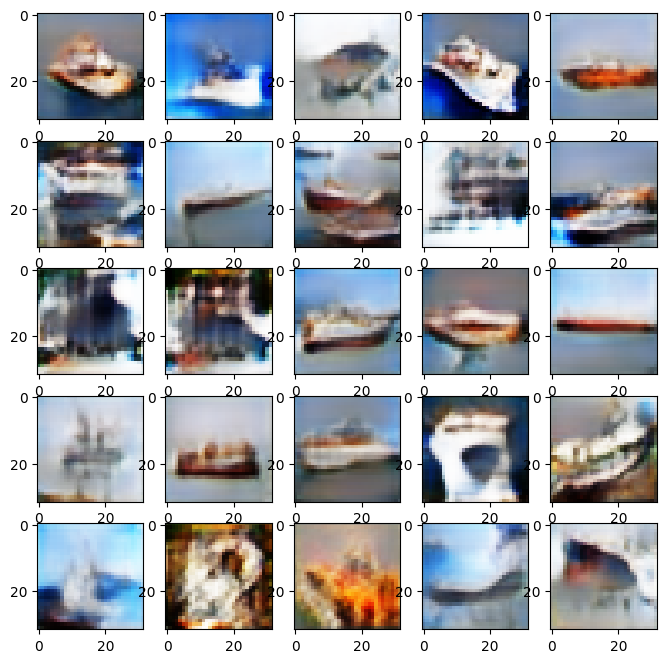

In [27]:
# Load Generator from final saved model

g_model = keras.models.load_model("g_model_032x032-tuned.sav")

# Generate 100 fake images by passing 100-dimensional random vectors through the Generator.
X_fake, _ = generate_fake_samples(g_model, 256, 100)

# Unnormalize to visualize image
X_fake = ((X_fake * 127.5) + 127.5).astype(np.uint8)

# Visualize the generated images
f, ax = plt.subplots(5, 5, figsize = (8, 8))
ax = ax.ravel()

for i in np.arange(25):
  ax[i].imshow(X_fake[i])

In [25]:
# Compress output folders for downloading
!zip -r /content/g_model_032x032-tuned.zip /content/g_model_032x032-tuned.sav
!zip -r /content/d_model_032x032-tuned.zip /content/d_model_032x032-tuned.sav
!zip -r /content/gan_model_032x032-tuned.zip /content/gan_model_032x032-tuned.sav

  adding: content/g_model_032x032-tuned.sav/ (stored 0%)
  adding: content/g_model_032x032-tuned.sav/keras_metadata.pb (deflated 94%)
  adding: content/g_model_032x032-tuned.sav/assets/ (stored 0%)
  adding: content/g_model_032x032-tuned.sav/fingerprint.pb (stored 0%)
  adding: content/g_model_032x032-tuned.sav/variables/ (stored 0%)
  adding: content/g_model_032x032-tuned.sav/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: content/g_model_032x032-tuned.sav/variables/variables.index (deflated 65%)
  adding: content/g_model_032x032-tuned.sav/saved_model.pb (deflated 90%)
  adding: content/d_model_032x032-tuned.sav/ (stored 0%)
  adding: content/d_model_032x032-tuned.sav/keras_metadata.pb (deflated 94%)
  adding: content/d_model_032x032-tuned.sav/assets/ (stored 0%)
  adding: content/d_model_032x032-tuned.sav/fingerprint.pb (stored 0%)
  adding: content/d_model_032x032-tuned.sav/variables/ (stored 0%)
  adding: content/d_model_032x032-tuned.sav/variables/variables.data-00